In [142]:
import numpy as np
from eigenshuffle import eigenshuffle
import csv

class Network:
    """ Standard framework of firing-rate neural networks """
    
    # Class level list of all instances 
    all = []
    
    # Class level attributes for dynamics of network
    _dt = 0.1
    _eta = 0.01
    _tau_x = 20
    _tau = 50
    _beta = 0.1
    
    def __init__(self, N):
        '''
            N : number of neurons in the network
        '''
        
        self.N = N
        
        # Connectivity Matrix
        self.W = 2*np.random.randn(N, N)/np.sqrt(N)

        # State Vector
        self.x = np.random.randn(N,1)
        self.y = self.x
        
        # Fluctuation phase is one of the dissipation, rate-control or decorrelation  
        self.__fluctuation_phase = 'rate-control'
        
        self.PHI0 = 2*np.random.rand(N, 1)- 1
        
        Network.all.append(self)
    
    
    @property
    def kisi(self):
        return np.random.normal(loc=0, scale=1/self.N, size=(self.N, self.N))
    
    @property
    def PHI(self):
        return np.tanh(self.x)
    
    def __update_network(self, b):
        """ One step dynamic of system (1 dt)"""     
        self.y = self.y + (self.x - self.y)*Network._dt/Network._tau
        
        self.x = self.x + (-self.x + np.matmul(self.W, self.PHI) + b) * Network._dt
        
        self.W = self.W + Network._eta*(self.__FluctuaionTerm() + self.__LearningTerm())*Network._dt 
    
    def __FluctuaionTerm(self):
        ''' Calculation of fluctuation term instantaneously at each integration step.
            Dependent on the phase of the network it could be :
            
            *** Activity independent rule ***
                - Dissipative synaptic dynamics
                
            *** Activity dependent rules ***
                - Stable post-synaptic firing-rate dynamics
                - Decorrelation rule 
        '''
        
        if self.__fluctuation_phase == 'dissipation':
            # dissipative synaptic dynamics
            return self.kisi - Network._beta*self.W
        
        elif self.__fluctuation_phase == 'rate-control':
            
            return self.kisi + np.matmul(self.PHI0 - self.PHI, self.PHI.T)*self.W
        
        elif self.__fluctuation_phase =='decorrelation':
            return self.kisi + np.identity(self.N)  
        
        else:
            raise Exception("fluctuation phase of system is invalid!")
        
    def __LearningTerm(self):
        return np.matmul(self.PHI, self.y.T) - np.matmul(self.y, self.PHI.T)
    
    
    def run_save(self, T, b):
        self.y_array = []
        self.w_array = []
        self.x_array = []
        print(Network._dt)
        for i in range(int(T/Network._dt)):
            self.x_array.append(self.x)
            self.y_array.append(self.y)
            self.w_array.append(self.W)
            self.__update_network(b=b)
       
        self.x_array = np.array(self.x_array)
        self.y_array = np.array(self.y_array)
        self.w_array = np.array(self.w_array)
            
    def __repr__(self):

        return f"Network: {self.N} neurons" 
    
    

In [143]:
network = Network(N=128)
network.run_save(T = 500, b = 0)


0.1


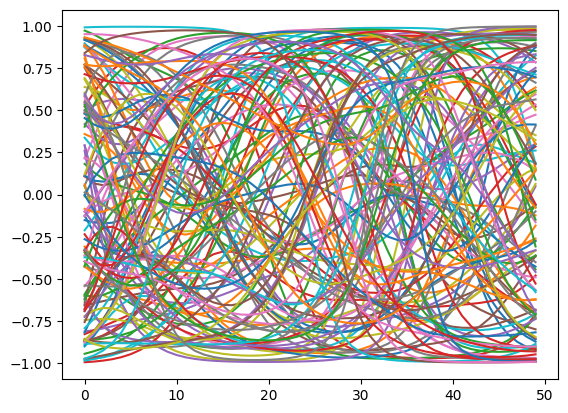

In [157]:
wseq = network.w_array

import matplotlib.pyplot as plt
# for i in range(10):
#     for j in range(10):
#          plt.plot(wseq[:, i, j])

plt.plot(np.tanh(network.x_array[0:50, :].squeeze()))
plt.show()

In [153]:
network.x_array.shape

(5000, 128, 1)